# AskMyBookmark — Orchestrator Pattern POC

This notebook builds a **LangGraph orchestrator** (supervisor pattern) for searching starred GitHub repositories.

## Architecture

The key insight guiding this design: **keyword extraction → synonym generation is always a fixed,
sequential pipeline** — there is no routing decision to make. Exposing them as separate agent tools
would let the LLM call them out of order or skip one. Instead they form a deterministic
**Query Prep sub-workflow** that always runs first.

The **Supervisor** is the only true agent: it reads the (now-enriched) state and decides which
retriever to invoke.

```
User Query
    │
    ▼
┌─────────────────────────────────────────┐
│       Query Prep (deterministic)        │
│   keyword_extractor → synonym_generator │
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│   Supervisor Agent (binary LLM router)  │
│   Decides: lexical | ensemble           │
└─────────────────────────────────────────┘
    │                         │
    ▼ (pure keywords only)    ▼ (default — everything else)
lexical_search           ensemble_search
(MultiMatch BM25          (EnsembleRetriever:
 + legacy BM25,            MultiMatch BM25
 union-dedup)              + Qdrant dense, RRF)
    │                         │
    └───────────┬─────────────┘
                ▼
          merge_results
                │
                ▼
         generate_answer
                │
                ▼
             Response
```

## Routing Heuristic

| Route | When to use |
|---|---|
| `ensemble` | **Default.** Any natural language, conceptual, or mixed query |
| `lexical` | Query is *literally just keywords* — no sentence structure (e.g. `"pytorch transformers"`) |

## State Shape

| Field | Populated by | Used by |
|---|---|---|
| `query` | user input | `keyword_extractor`, `ensemble_search`, `generate_answer` |
| `keywords` | `keyword_extractor` | `synonym_generator`, `lexical_search`, `ensemble_search` |
| `expansions` | `synonym_generator` | (debugging / display) |
| `bm25_terms` | `synonym_generator` | `lexical_search`, `ensemble_search` |
| `route` | `supervisor` | conditional edge routing |
| `bm25_results` | `lexical_search` / `ensemble_search` | `merge_results` |
| `vector_results` | (always empty — fused results go in `bm25_results`) | `merge_results` |
| `merged_results` | `merge_results` | `generate_answer` |
| `answer` | `generate_answer` | end user |


## 1. Imports & Environment Setup

In [1]:
import os
import pickle
import re
import uuid
from functools import partial
from typing import List, Dict, Any, Literal

import nest_asyncio
import numpy as np
import pandas as pd
import nltk
from dotenv import load_dotenv
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from pydantic import BaseModel, Field, ConfigDict
from textacy import preprocessing
from typing import TypedDict

from langchain.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.retrievers import BaseRetriever
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langgraph.graph import StateGraph, START, END
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from searcharray import SearchArray

nest_asyncio.apply()

# load environment variables — try notebooks/.env first (local dev), then root .env
for _env_path in ["notebooks/.env", ".env"]:
    if os.path.exists(_env_path):
        load_dotenv(_env_path)
        break

# download NLTK data if not already present
for _pkg in ["punkt", "stopwords", "wordnet", "punkt_tab"]:
    nltk.download(_pkg, quiet=True)

print("Imports OK")

Imports OK


## 2. Shared State

All nodes read from and write to a single `OrchestratorState` dict.  LangGraph merges the
partial dicts returned by each node into this shared state, so each node only needs to
return the keys it modifies.

In [2]:
class OrchestratorState(TypedDict):
    # ── Input ────────────────────────────────────────────────────────────────
    query: str                     # original user query (verbatim)

    # ── Query Prep (populated by deterministic sub-workflow) ─────────────────
    keywords: List[str]            # signal-bearing terms extracted from query
    expansions: List[Dict]         # per-keyword synonym objects (for inspection)
    bm25_terms: List[str]          # flat synonym list used to expand BM25 query

    # ── Supervisor ───────────────────────────────────────────────────────────
    route: str                     # "lexical" | "ensemble"

    # ── Retrieval results ────────────────────────────────────────────────────
    bm25_results: List[Document]
    vector_results: List[Document]
    merged_results: List[Document]

    # ── Final output ─────────────────────────────────────────────────────────
    answer: str

## 3. Query Prep — Deterministic Sub-Workflow

These two nodes **always run sequentially** before the supervisor sees the state.  There is no
routing decision here — the sequence is fixed in the graph edges.

### Why this is a workflow, not agent tools

If `keyword_extractor` and `synonym_generator` were exposed as separate tools to the supervisor,
an LLM could call them out of order, forget one, or call `synonym_generator` directly on raw
natural language.  Making them deterministic graph nodes eliminates that class of failure entirely.

### Design note: keyword extraction is idempotent on keyword-only queries

The extractor strips conversational filler and returns signal-bearing terms.  For a query that is
*already* just keywords (e.g. `"pytorch transformers"`), the extractor returns them unchanged.
This means we never need a separate "is this natural language?" classifier — just always run both
nodes.

In [3]:
# ── Structured output schemas ─────────────────────────────────────────────────

class KeywordExtractionOutput(BaseModel):
    keywords: List[str] = Field(
        description="Keywords extracted from the user query suitable for BM25 lexical search."
    )


class KeywordExpansion(BaseModel):
    keyword: str = Field(description="The original extracted keyword.")
    synonyms: List[str] = Field(
        description="Synonyms and closely related technical terms for this keyword "
                    "in the context of GitHub repos."
    )


class SynonymExpansionOutput(BaseModel):
    expansions: List[KeywordExpansion] = Field(
        description="Per-keyword synonym expansions."
    )


# ── System prompts ─────────────────────────────────────────────────────────────

KEYWORD_EXTRACTION_SYSTEM_PROMPT = """\
You are a search query keyword extractor for AskMyBookmark -- a conversational search \
assistant that helps people search through their starred GitHub repos. \
When given a user query, extract only the keywords that carry lexical search signal: \
repo names, technology names, programming languages, domain terms, and action verbs. \
Strip conversational filler, pronouns, and stopwords.\
Ignore extracting words related to repositories, repos, or GitHub in general.\
Ignore extracting words related to favorites or starred if related to repositories or GitHub in general.\
"""

SYNONYM_EXPANSION_SYSTEM_PROMPT = """\
You are a search term expander for AskMyBookmark -- a search assistant over starred GitHub repos. \
Given a list of search keywords, generate relevant synonyms and closely related technical terms \
for each keyword in the context of software, science, technology and GitHub repositories. \
Avoid duplicating the original keywords in the synonyms list.\
"""

# ── LLMs with structured output ───────────────────────────────────────────────

_base_llm = ChatOpenAI(model="gpt-4o-mini")
_keyword_extractor_llm = _base_llm.with_structured_output(KeywordExtractionOutput)
_synonym_generator_llm = _base_llm.with_structured_output(SynonymExpansionOutput)


# ── Graph nodes ───────────────────────────────────────────────────────────────

def keyword_extractor(state: OrchestratorState) -> dict:
    """Extract signal-bearing keywords from the raw user query."""
    response: KeywordExtractionOutput = _keyword_extractor_llm.invoke([
        SystemMessage(content=KEYWORD_EXTRACTION_SYSTEM_PROMPT),
        HumanMessage(content=state["query"]),
    ])
    return {"keywords": response.keywords}


def synonym_generator(state: OrchestratorState) -> dict:
    """Expand each keyword with synonyms; flatten into a single BM25 term list."""
    response: SynonymExpansionOutput = _synonym_generator_llm.invoke([
        SystemMessage(content=SYNONYM_EXPANSION_SYSTEM_PROMPT),
        HumanMessage(content=str(state["keywords"])),
    ])
    bm25_terms = [syn for exp in response.expansions for syn in exp.synonyms]
    return {
        "expansions": [exp.model_dump() for exp in response.expansions],
        "bm25_terms": bm25_terms,
    }


print("Query prep nodes defined")

Query prep nodes defined


## 4. Data Loading & Index Building

We reuse the exact same retriever setup from `retrievers.ipynb`:

- **`MultiMatchBM25Retriever`** — a custom LangChain retriever wrapping SearchArray's per-field
  BM25 with boost weights (`repo` × 3, `topics` × 2, `description` × 1.5, `content` × 1.0).
- **Qdrant in-memory dense retriever** — OpenAI `text-embedding-3-small` embeddings stored in
  a local Qdrant instance, queried with cosine similarity.

Both retrievers are built once at notebook startup and shared across graph invocations.

In [4]:
# ── Text pre-processing (mirrors retrievers.ipynb / ask_my_bookmark.py) ────────

MAX_CHARACTERS = 30_000
NAMESPACE = uuid.NAMESPACE_URL


def strip_markdown(text: str) -> str:
    """Remove common Markdown syntax while keeping inner text and emojis."""
    text = re.sub(r"^#{1,6}\s*", "", text, flags=re.MULTILINE)
    text = re.sub(r"`([^`]+)`", r"\1", text)
    text = re.sub(r"\*{1,2}([^*]+)\*{1,2}", r"\1", text)
    text = re.sub(r"_{1,2}([^_]+)_{1,2}", r"\1", text)
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text


def make_normalize_text_pipeline(*, unicode_form: str = "NFC"):
    return preprocessing.make_pipeline(
        strip_markdown,
        preprocessing.remove.html_tags,
        preprocessing.normalize.bullet_points,
        preprocessing.normalize.quotation_marks,
        partial(preprocessing.normalize.unicode, form=unicode_form),
        preprocessing.normalize.whitespace,
    )


_normalize_text = make_normalize_text_pipeline()


def repo_to_uuid(repo_name: str) -> str:
    return str(uuid.uuid5(NAMESPACE, repo_name))


def normalize_docs(docs: List[Dict[str, Any]]) -> str:
    content_str = "".join(doc["content"] + "\n\n" for doc in docs)
    truncated = content_str[:MAX_CHARACTERS] if len(content_str) > MAX_CHARACTERS else content_str
    return _normalize_text(truncated)


def preprocess_text(text: str | None) -> List[str]:
    """Tokenizer used by SearchArray BM25 — lowercase, remove stopwords, lemmatize."""
    if text is None:
        return []
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(w) for w in tokens]


print("Text preprocessing helpers defined")

Text preprocessing helpers defined


In [5]:
# ── MultiMatchBM25Retriever (from retrievers.ipynb) ────────────────────────────

def multi_match_search(
    query: str,
    df: pd.DataFrame,
    columns: List[str],
    boosts: Dict[str, float] | None = None,
) -> pd.DataFrame:
    """BM25 multi-field search with per-field boost weights and dismax scoring."""
    if boosts is None:
        boosts = {}
    boost_values = {col: boosts.get(col, 1.0) for col in columns}

    tokenized_queries = {
        col: df[col].array.tokenizer(query)
        for col in columns
    }

    field_scores = {
        col: np.asarray([df[col].array.score(term) for term in tokenized_queries[col]])
             * boost_values[col]
        for col in columns
    }

    num_terms = max((len(s) for s in field_scores.values()), default=0)
    if num_terms == 0:
        result = df.copy()
        result["score"] = 0.0
        return result

    best_term_scores = []
    for term_idx in range(num_terms):
        term_scores = [
            field_scores[col][term_idx]
            for col in columns
            if term_idx < len(field_scores[col])
        ]
        best_term_scores.append(np.max(term_scores, axis=0))

    result = df.copy()
    result["score"] = np.sum(best_term_scores, axis=0)
    return result.sort_values("score", ascending=False)


class MultiMatchBM25Retriever(BaseRetriever):
    """LangChain-compatible retriever wrapping SearchArray multi-field BM25."""

    model_config = ConfigDict(arbitrary_types_allowed=True)

    search_df: pd.DataFrame
    columns: List[str]
    boosts: Dict[str, float]
    k: int = 10

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: CallbackManagerForRetrieverRun,
    ) -> List[Document]:
        results = multi_match_search(
            query=query,
            df=self.search_df,
            columns=self.columns,
            boosts=self.boosts,
        )
        top_k = results[results["score"] > 0].head(self.k)
        return [
            Document(
                page_content=row["content"],
                metadata={
                    "id":          row["id"],
                    "repo":        row["repo"],
                    "description": row["description"],
                    "topics":      row["topics"],
                    "score":       float(row["score"]),
                },
            )
            for _, row in top_k.iterrows()
        ]


print("MultiMatchBM25Retriever defined")

MultiMatchBM25Retriever defined


In [6]:
# ── Load cached GitHub data ───────────────────────────────────────────────────

with open("../data/cached/github_data.pkl", "rb") as f:
    starred_repo_data = pickle.load(f)

print(f"Loaded {len(starred_repo_data)} starred repos")

# ── Build per-field search DataFrame ─────────────────────────────────────────

search_df = pd.DataFrame([
    {
        "id":          repo_to_uuid(repo["repo"]),
        "repo":        repo["repo"],
        "description": repo.get("description") or "",
        "topics":      " ".join(repo.get("topics", [])),
        "content":     f"Topics: {','.join(repo.get('topics', []))}\n" + normalize_docs(repo["docs"]),
    }
    for repo in starred_repo_data
])

# index each field with SearchArray for BM25 scoring
search_df["repo_idx"]        = SearchArray.index(search_df["repo"],        tokenizer=preprocess_text)
search_df["description_idx"] = SearchArray.index(search_df["description"], tokenizer=preprocess_text)
search_df["topics_idx"]      = SearchArray.index(search_df["topics"],      tokenizer=preprocess_text)
search_df["content_idx"]     = SearchArray.index(search_df["content"],     tokenizer=preprocess_text)

print(f"search_df built: {len(search_df)} rows")

Loaded 2049 starred repos
2026-03-16 21:24:37,075 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-16 21:24:37,075 - searcharray.indexing - INFO - 0 Batch Start tokenization
2026-03-16 21:24:37,076 - searcharray.indexing - INFO - Tokenizing 2049 documents
2026-03-16 21:24:38,558 - searcharray.indexing - INFO - Tokenization -- vstacking
2026-03-16 21:24:38,559 - searcharray.indexing - INFO - Tokenization -- DONE
2026-03-16 21:24:38,559 - searcharray.indexing - INFO - Inverting docs->terms
2026-03-16 21:24:38,559 - searcharray.indexing - INFO - Encoding positions to bit array
2026-03-16 21:24:38,564 - searcharray.indexing - INFO - Batch tokenization complete
2026-03-16 21:24:38,564 - searcharray.indexing - INFO - (main thread) Processing 1 batch results
2026-03-16 21:24:38,565 - searcharray.indexing - INFO - Indexing from tokenization complete
2026-03-16 21:24:38,566 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-16 21:24:38,567 - searcharray.ind

In [7]:
# ── Compute curated-list BM25 score (for document metadata) ──────────────────
#
# Repos that are themselves "awesome lists" get a boosted score stored in
# metadata so the answer generator can note it if relevant.

CURATED_QUERY = "awesome curated lists"
curated_results = multi_match_search(
    query=CURATED_QUERY,
    df=search_df,
    columns=["repo_idx", "topics_idx", "description_idx", "content_idx"],
    boosts={"repo_idx": 3.0, "topics_idx": 2.0, "description_idx": 1.5, "content_idx": 1.0},
)
curated_score_by_id = dict(
    zip(curated_results["id"], curated_results["score"].astype(float))
)

# ── Build LangChain Document objects (shared by both retrievers) ──────────────

documents = [
    Document(
        page_content=f"Topics: {','.join(repo.get('topics', []))}\n" + normalize_docs(repo["docs"]),
        metadata={
            "id":                (id_ := repo_to_uuid(repo["repo"])),
            "repo":              repo["repo"],
            "description":       repo.get("description") or "",
            "topics":            repo.get("topics", []),
            "language":          repo.get("language"),
            "doc_source":        repo.get("doc_source"),
            "stars":             repo.get("stars"),
            "url":               repo.get("url"),
            "curated_list_bm25": curated_score_by_id.get(id_, 0.0),
        },
    )
    for repo in starred_repo_data
]

# ── MultiMatchBM25 retriever ──────────────────────────────────────────────────

bm25_retriever = MultiMatchBM25Retriever(
    search_df=search_df,
    columns=["repo_idx", "topics_idx", "description_idx", "content_idx"],
    boosts={
        "repo_idx":        3.0,
        "topics_idx":      2.0,
        "description_idx": 1.5,
        "content_idx":     1.0,
    },
    k=10,
)

# ── Qdrant in-memory dense retriever ─────────────────────────────────────────

print("Building Qdrant index — this may take a minute...")

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
qdrant_client = QdrantClient(":memory:")
qdrant_client.create_collection(
    collection_name="ask_my_bookmark",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=qdrant_client,
    collection_name="ask_my_bookmark",
    embedding=embeddings,
)
vector_store.add_documents(documents)
dense_retriever = vector_store.as_retriever(search_kwargs={"k": 10})

# ── Ensemble retriever (RRF fusion of BM25 + dense) ──────────────────────────
#
# EnsembleRetriever combines results from both retrievers using Reciprocal Rank
# Fusion (RRF). Unlike running them sequentially and merging manually, RRF
# re-ranks by inverse rank position, giving a principled combined ranking.
# Used by the `ensemble_search` node when the supervisor routes to "ensemble".

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
)

# ── Legacy BM25 retriever (standard LangChain TF-IDF over full document text) ─
#
# Uses a different scoring algorithm than MultiMatchBM25Retriever — operates on
# the full document content rather than per-field boosted scoring.  Running both
# BM25 methods together for lexical search maximises recall: they surface
# different sets of candidate repos, as observed in retrievers.ipynb.

legacy_bm25_retriever = BM25Retriever.from_documents(documents)
legacy_bm25_retriever.k = 10

print("All retrievers ready (MultiMatch BM25, legacy BM25, dense, ensemble)")

Building Qdrant index — this may take a minute...
All retrievers ready (MultiMatch BM25, legacy BM25, dense, ensemble)


## 5. Search Nodes

Two search nodes cover the two routing outcomes:

| Node | Retriever(s) | Query input |
|---|---|---|
| `lexical_search` | `MultiMatchBM25Retriever` + `BM25Retriever` (merged) | `keywords` + `bm25_terms` joined as one expanded string |
| `ensemble_search` | `EnsembleRetriever` (MultiMatch BM25 + Qdrant dense via RRF) | expanded BM25 query |

### Why two BM25 methods in `lexical_search`?

`MultiMatchBM25Retriever` uses per-field boost weights (repo name × 3, topics × 2, etc.) and
SearchArray's scoring.  The legacy `BM25Retriever` uses standard LangChain TF-IDF over the full
document content.  They surface **different** candidate repos — running both together and
deduplicating maximises lexical recall, as observed in `retrievers.ipynb`.

A single `lexical_search` node runs both internally (no routing decision needed) and merges
via union-dedup, preserving MultiMatch results first.

### Why `ensemble_search` is the default

`EnsembleRetriever` fuses MultiMatch BM25 + Qdrant dense via **Reciprocal Rank Fusion (RRF)**:
each document scores `1 / (rank + k)` from each leg, summed and re-ranked.  This covers
*both* exact-term precision and semantic recall in a single pass — better than either alone
for natural language queries.  The supervisor routes here unless the query is pure keywords.

> **Note on query string for ensemble:** `EnsembleRetriever` passes the same query string to
> all child retrievers.  We pass the **expanded BM25 query** (keywords + synonyms) so the
> BM25 leg gets full term expansion benefit.  The dense leg is robust enough that synonym
> terms in the query string do not meaningfully hurt embedding quality.

In [8]:
def _build_expanded_query(state: OrchestratorState) -> str:
    """Join extracted keywords + synonyms into a single expanded query string for BM25."""
    all_terms = state["keywords"] + state["bm25_terms"]
    return " ".join(all_terms)


def lexical_search(state: OrchestratorState) -> dict:
    """Run dual-BM25 lexical search: MultiMatchBM25 + legacy BM25, merged by union-dedup.

    Both retrievers use the keyword-expanded query (original keywords + synonyms).
    MultiMatchBM25 uses per-field boost weights; legacy BM25 uses full-document
    TF-IDF.  They surface different candidates, so running both maximises recall.
    Results are merged: MultiMatch first (field-boosted precision), then any
    legacy-only results appended.
    """
    expanded_query = _build_expanded_query(state)

    multi_results = bm25_retriever.invoke(expanded_query)
    legacy_results = legacy_bm25_retriever.invoke(expanded_query)

    # union-dedup: MultiMatch first, then append legacy-only results
    seen = {doc.metadata.get("repo") for doc in multi_results}
    extra = [doc for doc in legacy_results if doc.metadata.get("repo") not in seen]

    return {"bm25_results": multi_results + extra, "vector_results": []}


def ensemble_search(state: OrchestratorState) -> dict:
    """Run EnsembleRetriever (RRF fusion of MultiMatch BM25 + Qdrant dense).

    Default route for natural language and mixed queries.  Passes the expanded
    query (keywords + synonyms) so the BM25 leg benefits from term expansion
    while the dense leg remains robust to the extra terms.
    Results stored in bm25_results so merge_results passes them through unchanged.
    """
    expanded_query = _build_expanded_query(state)
    results = ensemble_retriever.invoke(expanded_query)
    return {"bm25_results": results, "vector_results": []}


print("Search nodes defined")

Search nodes defined


## 6. Supervisor — LLM Router

The supervisor is the only agent in this graph.  It reads the enriched state (original query +
extracted keywords) and makes a **binary routing decision** via structured output:

| Route | Condition |
|---|---|
| `lexical` | Query is *literally* just keywords — no sentence structure, no natural language phrasing |
| `ensemble` | Everything else (default) — natural language, mixed, conceptual, or ambiguous queries |

This binary design keeps the supervisor's job simple and the error rate low.  `ensemble_search`
covers the vast majority of real queries; `lexical_search` is reserved for tight keyword inputs
where maximum BM25 recall is all that's needed.

Using structured output (`RouteDecision`) guarantees the node always writes a valid `route`
value that the conditional edge can act on — no string parsing required.

In [9]:
# ── Routing decision schema (binary) ─────────────────────────────────────────

class RouteDecision(BaseModel):
    route: Literal["lexical", "ensemble"] = Field(
        description=(
            "Search strategy to use. "
            "Choose 'lexical' ONLY when the query is literally just keywords with no "
            "sentence structure or natural language phrasing. "
            "Choose 'ensemble' for everything else — natural language, conceptual, "
            "mixed, or ambiguous queries."
        )
    )
    reasoning: str = Field(
        description="One sentence explaining why this route was chosen."
    )


SUPERVISOR_SYSTEM_PROMPT = """\
You are the search router for AskMyBookmark, an assistant that searches a user's starred GitHub repos.

Given a user query and its extracted keywords, choose one of two search strategies:

- "ensemble"  : DEFAULT. Use for any query that contains natural language, sentence structure,
                conversational phrasing, or a mix of concepts.  This covers the vast majority
                of queries and uses RRF fusion of BM25 + semantic search for best coverage.

- "lexical"   : Use ONLY when the query is literally just a list of keywords — no sentence
                structure, no verbs, no question words (e.g. "pytorch transformers cuda").
                In this case pure BM25 term matching is sufficient and preferred.

When in doubt, always prefer "ensemble".
"""

_supervisor_llm = ChatOpenAI(model="gpt-4o-mini").with_structured_output(RouteDecision)


def supervisor(state: OrchestratorState) -> dict:
    """LLM-based binary router: reads query + extracted keywords, writes route decision."""
    user_message = (
        f"Query: {state['query']}\n"
        f"Extracted keywords: {state['keywords']}"
    )
    decision: RouteDecision = _supervisor_llm.invoke([
        SystemMessage(content=SUPERVISOR_SYSTEM_PROMPT),
        HumanMessage(content=user_message),
    ])
    print(f"[supervisor] route={decision.route!r}  reason: {decision.reasoning}")
    return {"route": decision.route}


def route_after_supervisor(state: OrchestratorState) -> str:
    """Conditional edge function — returns the node name to visit next."""
    route_map = {
        "lexical":  "lexical_search",
        "ensemble": "ensemble_search",
    }
    return route_map[state["route"]]


print("Supervisor node defined")

Supervisor node defined


## 7. Merge & Answer Generation

### `merge_results`

Combines BM25 and vector results using a simple **Reciprocal Rank Fusion (RRF)**-style merge:
deduplicate by repo name while preserving the first-seen rank.  BM25 results are listed first
(they are more precise for expanded queries), then any vector-only results are appended.

### `generate_answer`

Uses the same RAG system prompt from `app/ask_my_bookmark.py` — grounding the LLM strictly
in the retrieved repository context, not its general knowledge of GitHub.

In [10]:
# ── Merge node ────────────────────────────────────────────────────────────────

def merge_results(state: OrchestratorState) -> dict:
    """
    Deduplicate and merge BM25 + vector results.

    Strategy: iterate BM25 results first (precise expanded-keyword matches),
    then append any vector-only results not already seen.  This gives a merged
    list that favours lexical precision while filling in semantic coverage.
    """
    seen_repos: set = set()
    merged: List[Document] = []

    for doc in (state["bm25_results"] + state["vector_results"]):
        repo = doc.metadata.get("repo")
        if repo and repo not in seen_repos:
            seen_repos.add(repo)
            merged.append(doc)

    return {"merged_results": merged}


# ── RAG system prompt (from ask_my_bookmark.py) ────────────────────────────────

RAG_SYSTEM_PROMPT = """You are AskMyBookmark, a personal research assistant with access to the user's GitHub starred repositories.

Your job is to help the user discover, recall, and explore repositories they have bookmarked on GitHub. You answer questions by reasoning over the retrieved repository context provided to you — not from your general knowledge of what exists on GitHub.

**Ground rules:**
- Only surface repositories that appear in the retrieved context below. Do not invent or suggest repositories that are not present in the context.
- If no retrieved repositories are relevant to the query, say so honestly and suggest the user try rephrasing or broadening their search.
- You may use your general knowledge to explain a topic or technology, but all repository recommendations must come exclusively from the retrieved context.

**When presenting results:**
- Always include the repository's full name (Repo) as a markdown link to its GitHub URL: [Repo](URL)
- Include a brief description of what the repo does (from the description and topics fields), written in your own words if the original description is terse or absent.
- Explain in 1–2 sentences *why* this repository is relevant to the user's query — this is the most important part.
- Group or rank results by relevance if there are several.
- If useful, note the primary programming language, star count, or topics to help the user evaluate the match.
"""

RAG_HUMAN_PROMPT_TEMPLATE = """User query: {query}

Retrieved repositories:
{context}
"""

_rag_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(RAG_SYSTEM_PROMPT),
    HumanMessagePromptTemplate.from_template(RAG_HUMAN_PROMPT_TEMPLATE),
])

_answer_llm = ChatOpenAI(model="gpt-4o-mini")
_rag_chain = _rag_prompt | _answer_llm


def _format_context(docs: List[Document]) -> str:
    """Serialise retrieved docs into the context block passed to the LLM."""
    parts = []
    for doc in docs:
        m = doc.metadata
        parts.append(
            f"Repo: {m.get('repo', 'unknown')}\n"
            f"URL: {m.get('url', '')}\n"
            f"Description: {m.get('description', '')}\n"
            f"Topics: {', '.join(m.get('topics', []))}\n"
            f"Language: {m.get('language', '')}\n"
            f"Stars: {m.get('stars', '')}\n"
            "---"
        )
    return "\n".join(parts)


def generate_answer(state: OrchestratorState) -> dict:
    """Generate a grounded answer from the merged retrieved documents."""
    context = _format_context(state["merged_results"])
    response = _rag_chain.invoke({"query": state["query"], "context": context})
    return {"answer": response.content}


print("Merge + answer nodes defined")

Merge + answer nodes defined


## 8. Graph Assembly

Wire all nodes together into a single `StateGraph`:

1. Fixed edges: `START → keyword_extractor → synonym_generator → supervisor`
2. Binary conditional edge from `supervisor` using `route_after_supervisor`:
   - `lexical` → `lexical_search` (pure keyword queries only)
   - `ensemble` → `ensemble_search` (all other queries — the default)
3. Both search nodes converge on `merge_results → generate_answer → END`

In [11]:
def build_orchestrator_graph():
    graph = StateGraph(OrchestratorState)

    # ── Register nodes ────────────────────────────────────────────────────────
    graph.add_node("keyword_extractor", keyword_extractor)
    graph.add_node("synonym_generator", synonym_generator)
    graph.add_node("supervisor",        supervisor)
    graph.add_node("lexical_search",    lexical_search)
    graph.add_node("ensemble_search",   ensemble_search)
    graph.add_node("merge_results",     merge_results)
    graph.add_node("generate_answer",   generate_answer)

    # ── Deterministic Query Prep chain ────────────────────────────────────────
    graph.add_edge(START,                "keyword_extractor")
    graph.add_edge("keyword_extractor",  "synonym_generator")
    graph.add_edge("synonym_generator",  "supervisor")

    # ── Binary conditional routing from supervisor ────────────────────────────
    graph.add_conditional_edges(
        "supervisor",
        route_after_supervisor,
        {
            "lexical_search":  "lexical_search",
            "ensemble_search": "ensemble_search",
        },
    )

    # ── Both search nodes converge on merge ───────────────────────────────────
    graph.add_edge("lexical_search",  "merge_results")
    graph.add_edge("ensemble_search", "merge_results")
    graph.add_edge("merge_results",   "generate_answer")
    graph.add_edge("generate_answer", END)

    return graph.compile()


orchestrator = build_orchestrator_graph()
print("Graph compiled successfully")

Graph compiled successfully


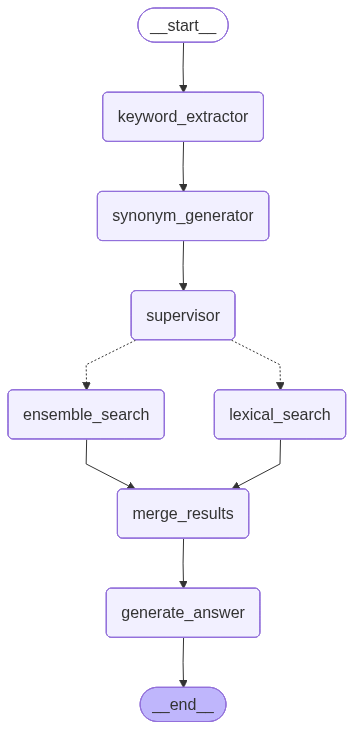

In [12]:
from IPython.display import Image, display

display(Image(orchestrator.get_graph().draw_mermaid_png()))

## 9. Test Queries

Three representative queries that exercise the two routing paths:

| Query | Expected route | Why |
|---|---|---|
| Natural language (deep learning) | `ensemble` | Natural language phrasing — default route |
| Keyword-only ("pytorch transformers") | `lexical` | Literally just keywords, no sentence structure |
| Conceptual (probability / Bayesian) | `ensemble` | Conceptual query — default route |

A helper function `run_query` prints the intermediate state so we can inspect what each
stage produced.

In [13]:
def run_query(query: str) -> dict:
    """Run a query through the orchestrator and display intermediate state."""
    print("=" * 70)
    print(f"QUERY: {query}")
    print("=" * 70)

    initial_state: OrchestratorState = {
        "query":          query,
        "keywords":       [],
        "expansions":     [],
        "bm25_terms":     [],
        "route":          "",
        "bm25_results":   [],
        "vector_results": [],
        "merged_results": [],
        "answer":         "",
    }

    result = orchestrator.invoke(initial_state)

    print(f"\n--- Keywords extracted: {result['keywords']}")
    print(f"--- BM25 synonym terms : {result['bm25_terms'][:5]} ... ({len(result['bm25_terms'])} total)")
    print(f"--- Route chosen       : {result['route']}")
    print(f"--- BM25 hits          : {len(result['bm25_results'])}")
    print(f"--- Vector hits        : {len(result['vector_results'])}")
    print(f"--- Merged results     : {len(result['merged_results'])} unique repos")
    print()
    print("ANSWER:")
    print(result["answer"])
    print()

    return result

In [14]:
# Test 1 — Natural language query (expects 'ensemble')
result1 = run_query("What are some top deep learning libraries I have starred?")

QUERY: What are some top deep learning libraries I have starred?
[supervisor] route='ensemble'  reason: The query contains natural language and a conversational structure, indicating a need for a broader search strategy.

--- Keywords extracted: ['deep learning', 'libraries']
--- BM25 synonym terms : ['neural networks', 'machine learning', 'artificial intelligence', 'supervised learning', 'unsupervised learning'] ... (18 total)
--- Route chosen       : ensemble
--- BM25 hits          : 17
--- Vector hits        : 0
--- Merged results     : 17 unique repos

ANSWER:
Here are some deep learning libraries and resources you have starred:

1. **[BVLC/caffe](https://github.com/BVLC/caffe)**  
   Caffe is a fast, open framework for deep learning designed for performance and flexibility in computer vision and machine learning tasks. This library is notable for its speed and efficiency, making it suitable for both research prototypes and production deployment. It has a star count of **34,780**.


In [15]:
# Test 2 — Keyword-only query (expects 'lexical')
result2 = run_query("pytorch transformers")

QUERY: pytorch transformers
[supervisor] route='lexical'  reason: The query consists solely of a list of keywords without any natural language or sentence structure.

--- Keywords extracted: ['pytorch', 'transformers']
--- BM25 synonym terms : ['tensor computation', 'deep learning framework', 'machine learning library', 'Neural network library', 'Torch'] ... (19 total)
--- Route chosen       : lexical
--- BM25 hits          : 17
--- Vector hits        : 0
--- Merged results     : 17 unique repos

ANSWER:
Here are some repositories related to "PyTorch" and "transformers" that you may find useful:

1. **[huggingface/transformers](https://github.com/huggingface/transformers)**  
   This repository provides a model-definition framework for state-of-the-art machine learning models across text, vision, audio, and multimodal applications, supporting both training and inference.  
   It's highly relevant as it specifically addresses transformer models, which are foundational for various NLP ta

In [16]:
# Test 3 — Conceptual / exploratory query (expects 'ensemble')
result3 = run_query("Do I have repos that help me understand probability and Bayesian reasoning?")

QUERY: Do I have repos that help me understand probability and Bayesian reasoning?
[supervisor] route='ensemble'  reason: The query contains natural language and a clear context, indicating an inquiry about repository relevance rather than just a list of keywords.

--- Keywords extracted: ['probability', 'Bayesian', 'reasoning']
--- BM25 synonym terms : ['likelihood', 'chance', 'statistical likelihood', 'probabilistic modeling', 'randomness'] ... (21 total)
--- Route chosen       : ensemble
--- BM25 hits          : 14
--- Vector hits        : 0
--- Merged results     : 14 unique repos

ANSWER:
Here are some repositories from your starred list that can help you understand probability and Bayesian reasoning:

1. **[bayesian-optimization/BayesianOptimization](https://github.com/bayesian-optimization/BayesianOptimization)**  
   This repository provides a Python implementation for global optimization using Gaussian processes. It is relevant as it allows users to apply Bayesian methods for 